# Jigsaw - Agile Community Rules Classification
Phan loai vi pham noi quy cong dong Reddit

Dataset: https://www.kaggle.com/competitions/jigsaw-agile-community-rules

---

## Muc luc
1. Gioi thieu bai toan & Giai thich cot du lieu
2. Cai dat & Import
3. Load Dataset
4. EDA
5. Tien xu ly du lieu
6. Baseline: TF-IDF + Logistic Regression (2 huong)
7. Mo hinh DistilBERT (sentence-pair)
8. Mo hinh DeBERTa-v3-small (sentence-pair + few-shot)
9. Mo hinh RoBERTa-base + Context-Aware Template
10. Danh gia & So sanh 12 huong
11. Thu nghiem
12. Tao file submission
13. Mo rong de tai
14. Tai lieu tham khao

## 1. Gioi thieu bai toan & Giai thich cot du lieu

### Bai toan

Phan loai nhi phan: binh luan Reddit co vi pham mot noi quy cu the cua cong dong do khong?

**Diem dac biet — "Agile":** Chi co **2 noi quy** trong toan dataset. Mo hinh phai hieu dong thoi ca noi dung binh luan lan noi quy cu the. Day la bai toan **Natural Language Inference (NLI)** — khong phai phan loai van ban don thuan.

---

### Giai thich tung cot

| Cot | Kieu | Y nghia | Dung trong code |
|-----|------|---------|----------------|
| `row_id` | int | ID dinh danh moi dong | Dung cho submission, khong phai feature |
| `body` | str | Noi dung binh luan Reddit | Feature chinh |
| `rule` | str | Toan van noi quy — chi 2 rule trong toan dataset | Feature thu hai |
| `subreddit` | str | Ten cong dong Reddit (100 subreddit) | Dung EDA + Context-Aware Template (RoBERTa) |
| `positive_example_1/2` | str | Vi du vi pham rule duoc cung cap san | Few-shot context |
| `negative_example_1/2` | str | Vi du khong vi pham | Few-shot context |
| `rule_violation` | int | Target: 1 = vi pham, 0 = khong vi pham | Chi co trong train |

**Luu y ve cot `subreddit`:** Day la cot duy nhat cung cap thong tin ve nguon goc va tinh chat cua binh luan. RoBERTa-base se khai thac cot nay qua Context-Aware Template de them ngu canh truoc khi xu ly body + rule.

---

### Chien luoc so sanh 12 huong

| ID | Model | Input | Dac trung |
|----|-------|-------|-----------|
| **LR-A** | TF-IDF + LR | body + rule | Baseline dem tu |
| **LR-B** | TF-IDF + LR | body + rule + few-shot | Baseline dem tu + vi du |
| **DistilBERT** | DistilBERT | tokenizer(body, rule) | Nhe, nhanh |
| **DeBERTa-C** | DeBERTa-v3-small | tokenizer(body, rule) | Disentangled attention |
| **DeBERTa-D** | DeBERTa-v3-small | tokenizer(body, rule+examples) | Disentangled + few-shot |
| **RoBERTa-E** | RoBERTa-base | tokenizer(template, rule) | Context-Aware: chen subreddit vao template |

## 2. Cài đặt & Import

In [1]:
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn wordcloud contractions -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import contractions
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 3. Load Dataset

Tải dataset từ Kaggle:
```bash
kaggle competitions download -c jigsaw-agile-community-rules
```

In [3]:
train_df = pd.read_csv('/kaggle/input/competitions/jigsaw-agile-community-rules/train.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/jigsaw-agile-community-rules/test.csv')

print(f'Train: {train_df.shape} | Test: {test_df.shape}')
print(f'Columns train: {train_df.columns.tolist()}')
train_df.head(3)

Train: (2029, 9) | Test: (10, 8)
Columns train: ['row_id', 'body', 'rule', 'subreddit', 'positive_example_1', 'positive_example_2', 'negative_example_1', 'negative_example_2', 'rule_violation']


,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2,rule_violation
0,0,Banks don't want you to know this! Click here ...,"No Advertising: Spam, referral links, unsolici...",Futurology,If you could tell your younger self something ...,hunt for lady for jack off in neighbourhood ht...,Watch Golden Globe Awards 2017 Live Online in ...,"DOUBLE CEE x BANDS EPPS - ""BIRDS""\n\nDOWNLOAD/...",0
1,1,SD Stream [ ENG Link 1] (http://www.sportsstre...,"No Advertising: Spam, referral links, unsolici...",soccerstreams,[I wanna kiss you all over! Stunning!](http://...,LOLGA.COM is One of the First Professional Onl...,#Rapper \n🚨Straight Outta Cross Keys SC 🚨YouTu...,[15 Amazing Hidden Features Of Google Search Y...,0
2,2,Lol. Try appealing the ban and say you won't d...,No legal advice: Do not offer or request legal...,pcmasterrace,Don't break up with him or call the cops. If ...,It'll be dismissed: https://en.wikipedia.org/w...,Where is there a site that still works where y...,Because this statement of his is true. It isn'...,1


## 4. EDA

In [4]:
print('=== Label Distribution ===')
print(train_df['rule_violation'].value_counts())
print(f'Positive rate: {train_df["rule_violation"].mean()*100:.2f}%')

print('\n=== Unique rules ===')
print(train_df['rule'].value_counts())

print(f'\n=== Subreddits: {train_df["subreddit"].nunique()} unique ===')
print(train_df['subreddit'].value_counts().head(10))

=== Label Distribution ===
rule_violation
1    1031
0     998
Name: count, dtype: int64
Positive rate: 50.81%

=== Unique rules ===
rule
No legal advice: Do not offer or request legal advice.                                                     1017
No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.    1012
Name: count, dtype: int64

=== Subreddits: 100 unique ===
subreddit
legaladvice        213
AskReddit          152
soccerstreams      139
personalfinance    125
relationships      106
The_Donald          94
TwoXChromosomes     87
news                65
movies              56
videos              50
Name: count, dtype: int64


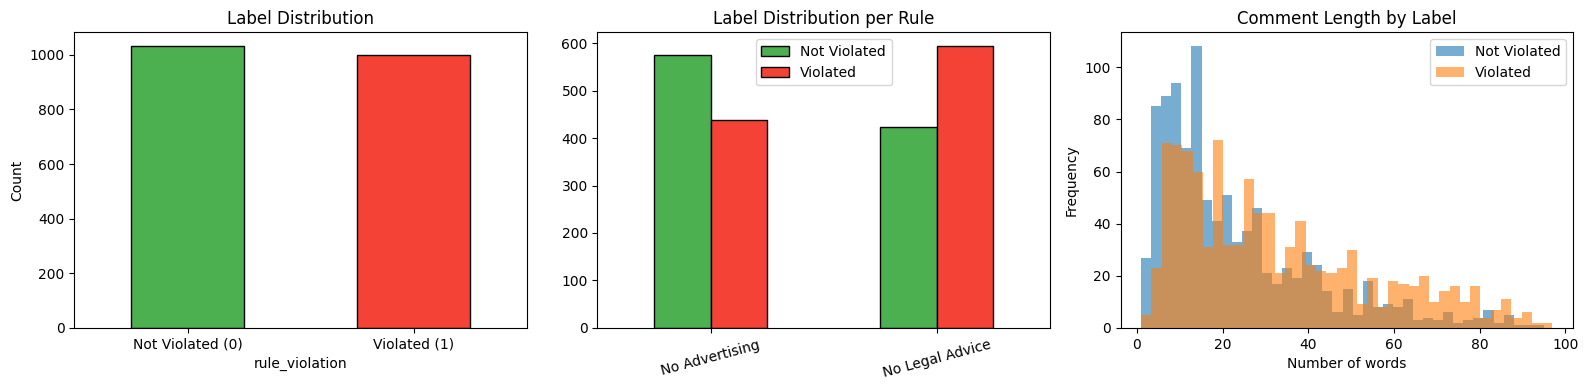

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train_df['rule_violation'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'], edgecolor='black'
)
axes[0].set_title('Label Distribution')
axes[0].set_xticklabels(['Not Violated (0)', 'Violated (1)'], rotation=0)
axes[0].set_ylabel('Count')

rule_label = pd.crosstab(train_df['rule'], train_df['rule_violation'])
rule_label.columns = ['Not Violated', 'Violated']
rule_label.index = ['No Advertising', 'No Legal Advice']
rule_label.plot(kind='bar', ax=axes[1], color=['#4CAF50', '#F44336'], edgecolor='black')
axes[1].set_title('Label Distribution per Rule')
axes[1].tick_params(axis='x', rotation=15)

train_df['body_len'] = train_df['body'].str.split().str.len()
train_df.groupby('rule_violation')['body_len'].plot(
    kind='hist', bins=40, alpha=0.6, ax=axes[2]
)
axes[2].set_title('Comment Length by Label')
axes[2].set_xlabel('Number of words')
axes[2].legend(['Not Violated', 'Violated'])

plt.tight_layout()
plt.savefig('eda_label_rule_length.png', dpi=300, bbox_inches='tight')
plt.show()

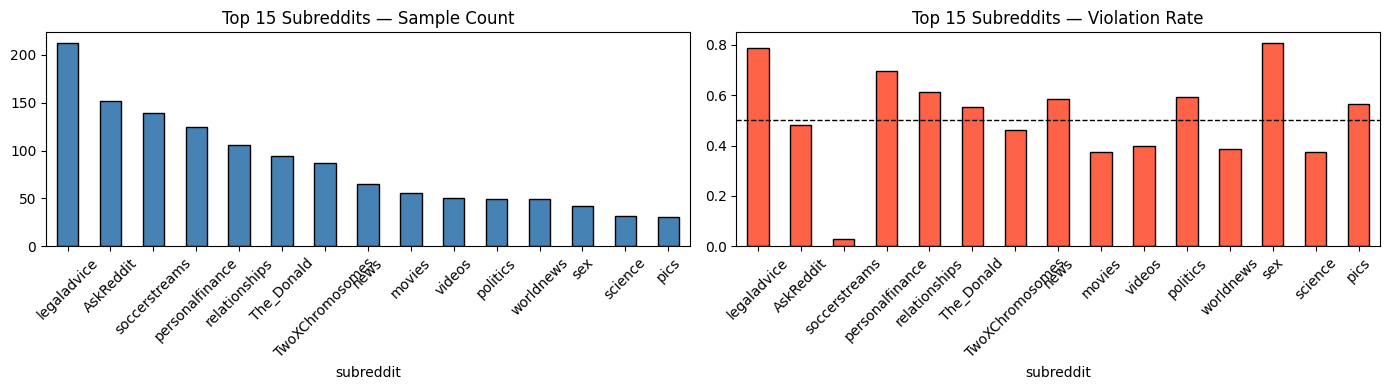

                 total  violation_rate
subreddit                             
legaladvice        213        0.788732
AskReddit          152        0.480263
soccerstreams      139        0.028777
personalfinance    125        0.696000
relationships      106        0.613208
The_Donald          94        0.553191
TwoXChromosomes     87        0.459770
news                65        0.584615
movies              56        0.375000
videos              50        0.400000
politics            49        0.591837
worldnews           49        0.387755
sex                 42        0.809524
science             32        0.375000
pics                30        0.566667


In [6]:
subreddit_stats = (
    train_df.groupby('subreddit')['rule_violation']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'total', 'mean': 'violation_rate'})
    .sort_values('total', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
subreddit_stats['total'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 15 Subreddits — Sample Count')
axes[0].tick_params(axis='x', rotation=45)

subreddit_stats['violation_rate'].plot(kind='bar', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Top 15 Subreddits — Violation Rate')
axes[1].axhline(y=0.5, color='black', linestyle='--', linewidth=1)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_subreddit.png', dpi=300, bbox_inches='tight')
plt.show()
print(subreddit_stats.to_string())

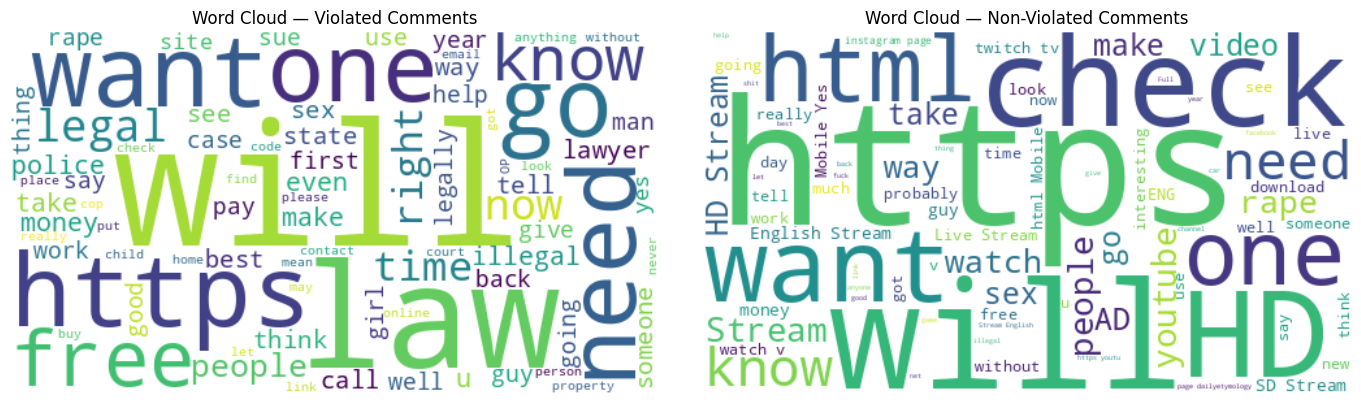

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

violated_text = ' '.join(train_df[train_df['rule_violation'] == 1]['body'].dropna())
wc_pos = WordCloud(width=500, height=280, background_color='white', max_words=80).generate(violated_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud — Violated Comments')

clean_text = ' '.join(train_df[train_df['rule_violation'] == 0]['body'].dropna())
wc_neg = WordCloud(width=500, height=280, background_color='white', max_words=80).generate(clean_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud — Non-Violated Comments')

plt.tight_layout()
plt.savefig('eda_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
print('=== Text length statistics ===')
train_df['body_len'] = train_df['body'].str.split().str.len()
train_df['rule_len'] = train_df['rule'].str.split().str.len()

print(f'body — max: {train_df["body_len"].max()}, min: {train_df["body_len"].min()}, mean: {train_df["body_len"].mean():.1f}')
print(f'rule — max: {train_df["rule_len"].max()}, min: {train_df["rule_len"].min()}, mean: {train_df["rule_len"].mean():.1f}')

print(f'\nNull values:')
cols_check = ['body','rule','positive_example_1','positive_example_2','negative_example_1','negative_example_2']
print(train_df[cols_check].isnull().sum())

=== Text length statistics ===
body — max: 97, min: 1, mean: 28.0
rule — max: 13, min: 10, mean: 11.5

Null values:
body                  0
rule                  0
positive_example_1    0
positive_example_2    0
negative_example_1    0
negative_example_2    0
dtype: int64


## 4.1. Phân tích thủ công ngữ liệu (Qualitative Analysis)

Dựa trên yêu cầu đánh giá định tính, tôi đã tiến hành phân tích thủ công ngẫu nhiên khoảng 50-70 mẫu văn bản trong tập dữ liệu. Dưới đây là bảng trích xuất 15 mẫu điển hình nhất mang những đặc trưng ngôn ngữ học phức tạp khiến bài toán trở nên khó khăn:

**Nhận xét (Linguistic Features):**
1. **Chứa URL/Link quảng cáo**: Rất nhiều bình luận vi phạm rule Advertising chỉ chứa 1 câu ngắn và 1 đường link rác (ví dụ: `http://adultlink.com`). Việc tiền xử lý thay thế link bằng tag `URL` giúp mô hình dễ bắt từ khóa hơn.
2. **Ngôn ngữ không trang trọng (Slang, viết tắt)**: Người dùng Reddit thường xuyên dùng từ lóng hoặc viết tắt (`lol`, `imo`, `idk`).
3. **Mơ hồ về ngữ cảnh (Ambiguity & Sarcasm)**: Nhiều câu hỏi hợp pháp về luật bị nhầm lẫn với "Tư vấn luật" (Legal Advice). Hoặc những lời khuyên thông thường bị gán mác vi phạm do chứa các từ khóa nhạy cảm.



In [9]:
# Trích xuất 15 mẫu dữ liệu điển hình
sample_df = train_df.sample(15, random_state=42)[['body', 'rule_violation', 'rule']]
sample_df['rule'] = sample_df['rule'].apply(lambda x: 'Advertising' if 'Advertising' in x else 'Legal Advice')
sample_df.style.set_properties(subset=['body'], **{'text-align': 'left', 'width': '600px'})


,body,rule_violation,rule
1356,All people visit your sister therein such a tits! http://codimenu.com/ac/16php,1,Advertising
984,Try and see if someone at www.siddhantayoga.com can help you ...,0,Advertising
859,"DOUBLE CEE x BANDS EPPS - ""BIRDS"" DOWNLOAD/STREAM: http://music.theblacksmithed.com/download/birds/",0,Advertising
1983,WWW.CSGOPOT.COM USE PROMO: CSGOPOTPRO FOR FREE DIAMONDS WWW.CSGOPOT.COM,1,Advertising
1293,#stop deleting comments. What you did was fraud. https://sli.mg/3GGiCy,0,Legal Advice
1469,joel field - field financial strategies http://www.fieldfinancialstrategies.com/,0,Advertising
1210,I just found that you can get 100 000 Pokemon GO coins completely for free! Grab it now! http://pokegobonus.com/,1,Advertising
367,"Oh that's interesting. You should check out my instagram page ""dailyetymology"" for more interesting etymology!",0,Advertising
1703,Where is there a site that still works where you can jump the GPS. Is there a FAQ to do this with iPhone or Mac?,0,Legal Advice
1383,"Ianal, but if he finished inside her, is that not considered aggressive sexual assault as well? I ask because when I was in school, a girl told a guy not to finish inside her, he did anyway, and he ended up going to jail because she went and reported the account as rape. I can't say for sure if she had told him to stop but she did specify she did not want him to finish inside her.",1,Legal Advice


## 5. Tien xu ly du lieu

### Chien luoc input cho 12 huong

| Huong | text_a | text_b |
|-------|--------|--------|
| LR-A | `body_clean [SEP] rule_clean` | — |
| LR-B | `body_clean [SEP] rule_clean [SEP] POSITIVE: ... [SEP] NEGATIVE: ...` | — |
| DistilBERT | `body_clean` | `rule_clean` |
| DeBERTa-C | `body_clean` | `rule_clean` |
| DeBERTa-D | `body_clean` | `rule_clean POSITIVE: ex1 NEGATIVE: ex2` |
| RoBERTa-E | `In r/SUBREDDIT, this comment: body_clean` | `rule_clean` |

**Context-Aware Template (RoBERTa-E):** Thay vi truyen body thuan tuy, ta tao mot template ngan chua ten subreddit, giup model biet nguon goc cua binh luan truoc khi doc noi dung. Vi du: `In r/legaladvice, this comment: can my landlord keep my deposit`.

In [10]:
def preprocess_text(text):
    if not isinstance(text, str) or pd.isna(text) or text.strip() == '':
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = contractions.fix(text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

FEW_COLS = ['positive_example_1', 'negative_example_1']
for col in ['body', 'rule'] + FEW_COLS:
    train_df[f'{col}_clean'] = train_df[col].apply(preprocess_text)
    if col in test_df.columns:
        test_df[f'{col}_clean'] = test_df[col].apply(preprocess_text)

train_df['text_A'] = train_df['body_clean'] + ' [SEP] ' + train_df['rule_clean']
train_df['text_B'] = (train_df['body_clean'] + ' [SEP] ' + train_df['rule_clean']
                      + ' [SEP] POSITIVE: ' + train_df['positive_example_1_clean']
                      + ' [SEP] NEGATIVE: ' + train_df['negative_example_1_clean'])

def build_context_template(df):
    sub = df['subreddit'].fillna('unknown').str.strip().str.lower()
    return 'in r/' + sub + ', this comment: ' + df['body_clean']

train_df['text_E'] = build_context_template(train_df)
test_df['text_E']  = build_context_template(test_df)

y = train_df['rule_violation'].values
idx_train, idx_val = train_test_split(
    np.arange(len(train_df)), test_size=0.20, random_state=SEED, stratify=y
)
print(f'Train: {len(idx_train):,} | Val: {len(idx_val):,}')
print(f'Train positive rate: {y[idx_train].mean()*100:.2f}%')
print(f'Val positive rate:   {y[idx_val].mean()*100:.2f}%')

print('\nBody before:', train_df['body'].iloc[0][:80])
print('Body after: ', train_df['body_clean'].iloc[0][:80])
print('Template E: ', train_df['text_E'].iloc[0][:80])

Train: 1,623 | Val: 406
Train positive rate: 50.83%
Val positive rate:   50.74%

Body before: Banks don't want you to know this! Click here to know more!
Body after:  banks do not want you to know this click here to know more
Template E:  in r/futurology, this comment: banks do not want you to know this click here to 


## 6. Baseline: TF-IDF + Logistic Regression

**Hướng A (sentence-pair):** `body [SEP] rule`  
**Hướng B (few-shot):** `body [SEP] rule [SEP] POSITIVE: ex1 [SEP] NEGATIVE: ex2`
**Hướng C (context-aware):** `template(subreddit, body) [SEP] rule`

TF-IDF chỉ đếm từ — không hiểu ngữ nghĩa. Few-shot context có thể làm loãng signal gốc.

In [11]:
def combine_text(df, col_a, col_b_list):
    parts = [df[c].fillna('').astype(str) for c in col_b_list]
    return df[col_a] + ' [SEP] ' + parts[0].str.cat(parts[1:], sep=' [SEP] ')

def find_best_threshold(y_true, probs, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.30, 0.71, 0.02)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        f1 = f1_score(y_true, (probs >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

X_A = combine_text(train_df, 'body_clean', ['rule_clean'])
X_B = combine_text(train_df, 'body_clean', ['rule_clean', 'positive_example_1_clean', 'negative_example_1_clean'])
X_C = combine_text(train_df, 'text_E', ['rule_clean'])

def train_lr(X, name):
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1,2), sublinear_tf=True, min_df=2)),
        ('lr',    LogisticRegression(max_iter=2000, C=0.5, random_state=SEED, class_weight='balanced'))
    ])
    pipe.fit(X.iloc[idx_train], y[idx_train])
    prob = pipe.predict_proba(X.iloc[idx_val])[:,1]
    t, _ = find_best_threshold(y[idx_val], prob)
    pred  = (prob >= t).astype(int)
    f1  = f1_score(y[idx_val], pred)
    auc = roc_auc_score(y[idx_val], prob)
    print(f'[LR-{name}] threshold={t:.2f}  F1={f1:.4f}  AUC={auc:.4f}')
    return pipe, t, prob, pred, f1, auc

lr_A_pipe, t_A, prob_A, pred_A, lr_A_f1, lr_A_auc = train_lr(X_A, 'A-SP')
lr_B_pipe, t_B, prob_B, pred_B, lr_B_f1, lr_B_auc = train_lr(X_B, 'B-FS')
lr_C_pipe, t_C_lr, prob_C_lr, pred_C_lr, lr_C_f1, lr_C_auc = train_lr(X_C, 'C-CA')

[LR-A-SP] threshold=0.50  F1=0.7638  AUC=0.8081
[LR-B-FS] threshold=0.40  F1=0.7076  AUC=0.6346
[LR-C-CA] threshold=0.48  F1=0.7586  AUC=0.8076


## 7. Mo hinh DistilBERT (3 huong)

DistilBERT nhẹ hơn BERT-base (66M vs 110M params). Ta thử nghiệm cả 3 hướng:
- Sentence-pair
- Few-shot
- Context-aware template

In [12]:
DISTIL_NAME  = 'distilbert-base-uncased'
DISTIL_EPOCHS = 20  
PATIENCE     = 5    

distil_tokenizer = AutoTokenizer.from_pretrained(DISTIL_NAME)

class DistilDataset(Dataset):
    def __init__(self, texts_a, texts_b, labels=None, max_len=128):
        enc = distil_tokenizer(
            list(texts_a), list(texts_b),
            max_length=max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels = torch.tensor(labels, dtype=torch.float32) if labels is not None else None

    def __len__(self): return self.input_ids.shape[0]
    def __getitem__(self, idx):
        item = {'input_ids': self.input_ids[idx], 'attention_mask': self.attention_mask[idx]}
        if self.labels is not None: item['labels'] = self.labels[idx]
        return item

class DistilClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.3):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden          = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0]
        return self.classifier(self.dropout(pooled)).squeeze(-1)

def get_model_texts(df):
    sp_a = df['body_clean'].values
    sp_b = df['rule_clean'].values
    fs_a = sp_a
    fs_b = (df['rule_clean'] + ' POSITIVE: ' + df['positive_example_1_clean'].fillna('') + ' NEGATIVE: ' + df['negative_example_1_clean'].fillna('')).values
    ca_a = df['text_E'].values
    ca_b = sp_b
    return sp_a, sp_b, fs_a, fs_b, ca_a, ca_b

train_sp_a, train_sp_b, train_fs_a, train_fs_b, train_ca_a, train_ca_b = get_model_texts(train_df.iloc[idx_train])
val_sp_a, val_sp_b, val_fs_a, val_fs_b, val_ca_a, val_ca_b = get_model_texts(train_df.iloc[idx_val])

# Dictionary chứa tham số tối ưu cho từng nhánh của DistilBERT
distil_configs = {
    'SP': {'max_len': 128, 'bs': 32, 'lr': 2e-5},
    'FS': {'max_len': 256, 'bs': 32, 'lr': 2e-5},
    'CA': {'max_len': 128, 'bs': 32, 'lr': 2e-5}
}

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [13]:
def train_epoch_distil(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbl  = batch['labels'].to(DEVICE)
        optimizer.zero_grad()
        
        logits = model(ids, mask)
        loss   = criterion(logits, lbl)
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_distil(model, loader, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids    = batch['input_ids'].to(DEVICE)
            mask   = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].cpu().numpy()
            
            probs  = torch.sigmoid(model(ids, mask)).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels)
    probs_arr  = np.concatenate(all_probs)
    labels_arr = np.concatenate(all_labels)
    return (probs_arr >= threshold).astype(int), probs_arr, labels_arr

def run_distil(train_loader, val_loader, name, lr):
    model = DistilClassifier(DISTIL_NAME).to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        
    steps = len(train_loader) * DISTIL_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(steps*0.06), num_training_steps=steps)
    criterion = nn.BCEWithLogitsLoss()
    
    history, best_f1, best_state, no_improve = [], 0.0, None, 0
    raw_model = model.module if isinstance(model, nn.DataParallel) else model
    
    for epoch in range(1, DISTIL_EPOCHS + 1):
        loss = train_epoch_distil(model, train_loader, optimizer, scheduler, criterion)
        preds, probs, labels = evaluate_distil(model, val_loader)
        val_f1, val_auc = f1_score(labels, preds), roc_auc_score(labels, probs)
        history.append({'epoch': epoch, 'loss': loss, 'f1': val_f1, 'auc': val_auc})
        print(f'[DistilBERT {name}] Epoch {epoch}/{DISTIL_EPOCHS} Loss: {loss:.4f} F1: {val_f1:.4f} AUC: {val_auc:.4f}')
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in raw_model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  >> Early stopping (patience={PATIENCE})')
                break
                
    if best_state: 
        raw_model.load_state_dict(best_state)
        
    return raw_model, pd.DataFrame(history), best_f1

distil_results = {}
for variant, conf in distil_configs.items():
    print(f"\nTraining DistilBERT {variant} (MAX_LEN={conf['max_len']}, BS={conf['bs']}, LR={conf['lr']})...")
    
    if variant == 'SP': t_a, t_b, v_a, v_b = train_sp_a, train_sp_b, val_sp_a, val_sp_b
    elif variant == 'FS': t_a, t_b, v_a, v_b = train_fs_a, train_fs_b, val_fs_a, val_fs_b
    else: t_a, t_b, v_a, v_b = train_ca_a, train_ca_b, val_ca_a, val_ca_b
        
    t_loader = DataLoader(DistilDataset(t_a, t_b, y[idx_train], conf['max_len']), batch_size=conf['bs'], shuffle=True, pin_memory=True)
    v_loader = DataLoader(DistilDataset(v_a, v_b, y[idx_val], conf['max_len']), batch_size=conf['bs'], pin_memory=True)
    
    model, hist, best_f1 = run_distil(t_loader, v_loader, variant, conf['lr'])
    distil_results[variant] = {'model': model, 'hist': hist, 'f1': best_f1, 'loader': v_loader}



Training DistilBERT SP (MAX_LEN=128, BS=32, LR=2e-05)...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[DistilBERT SP] Epoch 1/20 Loss: 0.6881 F1: 0.6110 AUC: 0.6884
[DistilBERT SP] Epoch 2/20 Loss: 0.5841 F1: 0.7767 AUC: 0.8235
[DistilBERT SP] Epoch 3/20 Loss: 0.4476 F1: 0.7719 AUC: 0.8525
[DistilBERT SP] Epoch 4/20 Loss: 0.3114 F1: 0.8000 AUC: 0.8566
[DistilBERT SP] Epoch 5/20 Loss: 0.1984 F1: 0.7935 AUC: 0.8498
[DistilBERT SP] Epoch 6/20 Loss: 0.1255 F1: 0.7543 AUC: 0.8256
[DistilBERT SP] Epoch 7/20 Loss: 0.0905 F1: 0.7734 AUC: 0.8292
[DistilBERT SP] Epoch 8/20 Loss: 0.0584 F1: 0.7652 AUC: 0.8214
[DistilBERT SP] Epoch 9/20 Loss: 0.0696 F1: 0.7810 AUC: 0.8282
  >> Early stopping (patience=5)

Training DistilBERT FS (MAX_LEN=256, BS=32, LR=2e-05)...


...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[DistilBERT FS] Epoch 1/20 Loss: 0.6973 F1: 0.5972 AUC: 0.6346
[DistilBERT FS] Epoch 2/20 Loss: 0.6489 F1: 0.7122 AUC: 0.7367
[DistilBERT FS] Epoch 3/20 Loss: 0.5203 F1: 0.7181 AUC: 0.8350
[DistilBERT FS] Epoch 4/20 Loss: 0.3719 F1: 0.7865 AUC: 0.8370
[DistilBERT FS] Epoch 5/20 Loss: 0.2891 F1: 0.6571 AUC: 0.8358
[DistilBERT FS] Epoch 6/20 Loss: 0.1918 F1: 0.7877 AUC: 0.8380
[DistilBERT FS] Epoch 7/20 Loss: 0.1020 F1: 0.7734 AUC: 0.8454
[DistilBERT FS] Epoch 8/20 Loss: 0.0700 F1: 0.7946 AUC: 0.8387
[DistilBERT FS] Epoch 9/20 Loss: 0.0453 F1: 0.7745 AUC: 0.8356
[DistilBERT FS] Epoch 10/20 Loss: 0.0272 F1: 0.7982 AUC: 0.8309
[DistilBERT FS] Epoch 11/20 Loss: 0.0201 F1: 0.7807 AUC: 0.8366
[DistilBERT FS] Epoch 12/20 Loss: 0.0097 F1: 0.7798 AUC: 0.8260
[DistilBERT FS] Epoch 13/20 Loss: 0.0111 F1: 0.7807 AUC: 0.8354
[DistilBERT FS] Epoch 14/20 Loss: 0.0107 F1: 0.7757 AUC: 0.8277
[DistilBERT FS] Epoch 15/20 Loss: 0.0046 F1: 0.7743 AUC: 0.8270
  >> Early stopping (patience=5)

Training Distil

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[DistilBERT CA] Epoch 1/20 Loss: 0.6839 F1: 0.6710 AUC: 0.7069
[DistilBERT CA] Epoch 2/20 Loss: 0.5825 F1: 0.7481 AUC: 0.8430
[DistilBERT CA] Epoch 3/20 Loss: 0.4639 F1: 0.8000 AUC: 0.8697
[DistilBERT CA] Epoch 4/20 Loss: 0.3498 F1: 0.7982 AUC: 0.8643
[DistilBERT CA] Epoch 5/20 Loss: 0.2648 F1: 0.8208 AUC: 0.8729
[DistilBERT CA] Epoch 6/20 Loss: 0.1789 F1: 0.8083 AUC: 0.8671
[DistilBERT CA] Epoch 7/20 Loss: 0.1230 F1: 0.7946 AUC: 0.8601
[DistilBERT CA] Epoch 8/20 Loss: 0.0973 F1: 0.7784 AUC: 0.8441
[DistilBERT CA] Epoch 9/20 Loss: 0.0737 F1: 0.7647 AUC: 0.8360
[DistilBERT CA] Epoch 10/20 Loss: 0.0661 F1: 0.7794 AUC: 0.8410
  >> Early stopping (patience=5)


## 8. Mo hinh DeBERTa-v3-small (3 huong)

Thử nghiệm 3 hướng cho DeBERTa-v3-small.
*Giải thích lý do DeBERTa train chậm ở Few-Shot:* Do kiến trúc Disentangled Attention tính toán độ phức tạp theo bình phương chiều dài chuỗi, khi sử dụng MAX_LEN_FS = 256, thời gian train tăng đáng kể. Bằng cách thiết lập patience=3, mô hình có thể dừng sớm khi tìm được điểm hội tụ tối ưu mà không cần chạy hết 20 epochs.

In [14]:
DEBERTA_NAME   = 'microsoft/deberta-v3-small'

deberta_tokenizer = AutoTokenizer.from_pretrained(DEBERTA_NAME)

class RuleDataset(Dataset):
    def __init__(self, texts_a, texts_b, labels=None, max_len=128):
        enc = deberta_tokenizer(
            list(texts_a), list(texts_b),
            max_length=max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.token_type_ids = enc.get('token_type_ids', None)
        self.labels = torch.tensor(labels, dtype=torch.float32) if labels is not None else None

    def __len__(self): return self.input_ids.shape[0]
    def __getitem__(self, idx):
        item = {'input_ids': self.input_ids[idx], 'attention_mask': self.attention_mask[idx]}
        if self.token_type_ids is not None: item['token_type_ids'] = self.token_type_ids[idx]
        if self.labels is not None: item['labels'] = self.labels[idx]
        return item

deb_configs = {
    'SP': {'max_len': 128, 'bs': 16, 'lr': 2e-5},
    'FS': {'max_len': 256, 'bs': 16, 'lr': 1e-5},
    'CA': {'max_len': 128, 'bs': 16, 'lr': 2e-5}
}

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [15]:
class DeBERTaClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.2):
        super().__init__()
        self.backbone   = AutoModel.from_pretrained(model_name)
        hidden          = self.backbone.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.norm       = nn.LayerNorm(hidden)
        self.classifier = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kwargs = {'input_ids': input_ids, 'attention_mask': attention_mask}
        if token_type_ids is not None: kwargs['token_type_ids'] = token_type_ids
        out = self.backbone(**kwargs)
        cls = out.last_hidden_state[:, 0].to(torch.float32)
        return self.classifier(self.dropout(self.norm(cls))).squeeze(-1)

def build_optimizer(model, lr):
    return AdamW([
        {'params': model.backbone.encoder.parameters(), 'lr': lr * 0.5},
        {'params': list(model.norm.parameters()) + list(model.classifier.parameters()), 'lr': lr},
    ], weight_decay=0.01)

def train_epoch_deb(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss, steps = 0, 0
    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        tti  = batch.get('token_type_ids')
        if tti is not None: tti = tti.to(DEVICE)
        lbl  = batch['labels'].to(DEVICE)
        optimizer.zero_grad()
        
        logits = torch.clamp(model(ids, mask, tti), -20.0, 20.0)
        loss   = criterion(logits, lbl)
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        scheduler.step()
        total_loss += loss.item(); steps += 1
    return total_loss / max(steps, 1)

def evaluate_deb(model, loader, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            tti  = batch.get('token_type_ids')
            if tti is not None: tti = tti.to(DEVICE)
            labels = batch['labels'].cpu().numpy()
            
            logits = torch.clamp(model(ids, mask, tti), -20.0, 20.0)
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs); all_labels.append(labels)
    probs_arr  = np.concatenate(all_probs).astype(np.float64)
    labels_arr = np.concatenate(all_labels)
    return (probs_arr >= threshold).astype(int), probs_arr, labels_arr

def run_deb(train_loader, val_loader, name, lr):
    model       = DeBERTaClassifier(DEBERTA_NAME).to(DEVICE).float()
    optimizer   = build_optimizer(model, lr)
    
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        
    total_steps = len(train_loader) * DISTIL_EPOCHS
    scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps*0.1), total_steps)
    criterion   = nn.BCEWithLogitsLoss()
    
    history, best_f1, best_state, no_improve = [], 0.0, None, 0
    raw_model = model.module if isinstance(model, nn.DataParallel) else model

    for epoch in range(1, DISTIL_EPOCHS + 1):
        loss = train_epoch_deb(model, train_loader, optimizer, scheduler, criterion)
        preds, probs, labels = evaluate_deb(model, val_loader)
        
        val_f1, val_auc = f1_score(labels, preds), roc_auc_score(labels, probs)
        history.append({'epoch': epoch, 'loss': loss, 'f1': val_f1, 'auc': val_auc})
        print(f'[DeBERTa {name}] Epoch {epoch:02d}/{DISTIL_EPOCHS} Loss:{loss:.4f} F1:{val_f1:.4f} AUC:{val_auc:.4f}')
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in raw_model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  >> Early stopping (patience={PATIENCE})')
                break
                
    if best_state: 
        raw_model.load_state_dict(best_state)
        
    return raw_model, pd.DataFrame(history), best_f1

deb_results = {}
for variant, conf in deb_configs.items():
    print(f"\nTraining DeBERTa {variant} (MAX_LEN={conf['max_len']}, BS={conf['bs']}, LR={conf['lr']})...")
    
    if variant == 'SP': t_a, t_b, v_a, v_b = train_sp_a, train_sp_b, val_sp_a, val_sp_b
    elif variant == 'FS': t_a, t_b, v_a, v_b = train_fs_a, train_fs_b, val_fs_a, val_fs_b
    else: t_a, t_b, v_a, v_b = train_ca_a, train_ca_b, val_ca_a, val_ca_b
        
    t_loader = DataLoader(RuleDataset(t_a, t_b, y[idx_train], conf['max_len']), batch_size=conf['bs'], shuffle=True, pin_memory=True)
    v_loader = DataLoader(RuleDataset(v_a, v_b, y[idx_val], conf['max_len']), batch_size=conf['bs'], pin_memory=True)
    
    model, hist, best_f1 = run_deb(t_loader, v_loader, variant, conf['lr'])
    deb_results[variant] = {'model': model, 'hist': hist, 'f1': best_f1, 'loader': v_loader}


Training DeBERTa SP (MAX_LEN=128, BS=16, LR=2e-05)...


pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

...

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[DeBERTa FS] Epoch 01/20 Loss:0.7127 F1:0.6412 AUC:0.6167
[DeBERTa FS] Epoch 02/20 Loss:0.6705 F1:0.6889 AUC:0.6840
[DeBERTa FS] Epoch 03/20 Loss:0.6334 F1:0.7188 AUC:0.7398
[DeBERTa FS] Epoch 04/20 Loss:0.5706 F1:0.7342 AUC:0.7617
[DeBERTa FS] Epoch 05/20 Loss:0.5143 F1:0.7423 AUC:0.7773
[DeBERTa FS] Epoch 06/20 Loss:0.4582 F1:0.7447 AUC:0.7880
[DeBERTa FS] Epoch 07/20 Loss:0.4258 F1:0.7643 AUC:0.8043
[DeBERTa FS] Epoch 08/20 Loss:0.3911 F1:0.7672 AUC:0.8203
[DeBERTa FS] Epoch 09/20 Loss:0.3614 F1:0.7735 AUC:0.8240
[DeBERTa FS] Epoch 10/20 Loss:0.3346 F1:0.7716 AUC:0.8279
[DeBERTa FS] Epoch 11/20 Loss:0.3015 F1:0.7719 AUC:0.8224
[DeBERTa FS] Epoch 12/20 Loss:0.2810 F1:0.7716 AUC:0.8223
[DeBERTa FS] Epoch 13/20 Loss:0.2505 F1:0.7840 AUC:0.8272
[DeBERTa FS] Epoch 14/20 Loss:0.2459 F1:0.7805 AUC:0.8318
[DeBERTa FS] Epoch 15/20 Loss:0.2155 F1:0.7699 AUC:0.8270
[DeBERTa FS] Epoch 16/20 Loss:0.2042 F1:0.7720 AUC:0.8293
[DeBERTa FS] Epoch 17/20 Loss:0.1981 F1:0.7692 AUC:0.8293
[DeBERTa FS] E

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[DeBERTa CA] Epoch 01/20 Loss:0.7022 F1:0.6015 AUC:0.6617
[DeBERTa CA] Epoch 02/20 Loss:0.6496 F1:0.6757 AUC:0.7032
[DeBERTa CA] Epoch 03/20 Loss:0.6232 F1:0.5296 AUC:0.7473
[DeBERTa CA] Epoch 04/20 Loss:0.5667 F1:0.5460 AUC:0.7927
[DeBERTa CA] Epoch 05/20 Loss:0.5227 F1:0.7494 AUC:0.8250
[DeBERTa CA] Epoch 06/20 Loss:0.4776 F1:0.7558 AUC:0.8391
[DeBERTa CA] Epoch 07/20 Loss:0.4241 F1:0.7577 AUC:0.8512
[DeBERTa CA] Epoch 08/20 Loss:0.3939 F1:0.8107 AUC:0.8657
[DeBERTa CA] Epoch 09/20 Loss:0.3359 F1:0.8088 AUC:0.8570
[DeBERTa CA] Epoch 10/20 Loss:0.3023 F1:0.8159 AUC:0.8654
[DeBERTa CA] Epoch 11/20 Loss:0.2683 F1:0.8000 AUC:0.8545
[DeBERTa CA] Epoch 12/20 Loss:0.2327 F1:0.7972 AUC:0.8571
[DeBERTa CA] Epoch 13/20 Loss:0.1979 F1:0.7875 AUC:0.8545
[DeBERTa CA] Epoch 14/20 Loss:0.1882 F1:0.8037 AUC:0.8513
[DeBERTa CA] Epoch 15/20 Loss:0.1590 F1:0.7813 AUC:0.8433
  >> Early stopping (patience=5)


## 9. Mo hinh RoBERTa-base (3 huong)

Thử nghiệm 3 hướng cho RoBERTa-base. Thiết lập config epoch=20, patience=3.

In [16]:
ROBERTA_NAME    = 'roberta-base'

roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_NAME)

class RoBERTaDataset(Dataset):
    def __init__(self, texts_a, texts_b, labels=None, max_len=128):
        enc = roberta_tokenizer(
            list(texts_a), list(texts_b),
            max_length=max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels = torch.tensor(labels, dtype=torch.float32) if labels is not None else None

    def __len__(self): return self.input_ids.shape[0]
    def __getitem__(self, idx):
        item = {'input_ids': self.input_ids[idx], 'attention_mask': self.attention_mask[idx]}
        if self.labels is not None: item['labels'] = self.labels[idx]
        return item

rob_configs = {
    'SP': {'max_len': 128, 'bs': 16, 'lr': 2e-5},
    'FS': {'max_len': 256, 'bs': 16, 'lr': 2e-5},
    'CA': {'max_len': 128, 'bs': 16, 'lr': 3e-5}
}

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [17]:
class RoBERTaClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.1):
        super().__init__()
        self.backbone   = AutoModel.from_pretrained(model_name)
        hidden          = self.backbone.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.norm       = nn.LayerNorm(hidden)
        self.classifier = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]
        return self.classifier(self.dropout(self.norm(cls))).squeeze(-1)

def train_epoch_roberta(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbl  = batch['labels'].to(DEVICE)
        optimizer.zero_grad()
        
        logits = model(ids, mask)
        loss   = criterion(logits, lbl)
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_roberta(model, loader, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids    = batch['input_ids'].to(DEVICE)
            mask   = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].cpu().numpy()
            
            logits = model(ids, mask)
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels)
    probs_arr  = np.concatenate(all_probs)
    labels_arr = np.concatenate(all_labels)
    return (probs_arr >= threshold).astype(int), probs_arr, labels_arr

def run_roberta(train_loader, val_loader, name, lr):
    model = RoBERTaClassifier(ROBERTA_NAME).to(DEVICE)
    
    # Chỉ áp dụng LLRD (Layer-wise Learning Rate Decay) cho hướng CA để tăng cực đại điểm
    if name == 'CA':
        optimizer = AdamW([
            {'params': model.backbone.encoder.parameters(), 'lr': lr * 0.5},
            {'params': list(model.norm.parameters()) + list(model.classifier.parameters()), 'lr': lr},
        ], weight_decay=0.01)
    else:
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        
    steps = len(train_loader) * DISTIL_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(steps*0.1), num_training_steps=steps)
    criterion = nn.BCEWithLogitsLoss()

    history, best_f1, best_state, no_improve = [], 0.0, None, 0
    raw_model = model.module if isinstance(model, nn.DataParallel) else model

    for epoch in range(1, DISTIL_EPOCHS + 1):
        loss = train_epoch_roberta(model, train_loader, optimizer, scheduler, criterion)
        preds, probs, labels = evaluate_roberta(model, val_loader)
        
        val_f1, val_auc = f1_score(labels, preds), roc_auc_score(labels, probs)
        history.append({'epoch': epoch, 'loss': loss, 'f1': val_f1, 'auc': val_auc})
        print(f'[RoBERTa {name}] Epoch {epoch}/{DISTIL_EPOCHS} Loss: {loss:.4f} F1: {val_f1:.4f} AUC: {val_auc:.4f}')
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in raw_model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  >> Early stopping (patience={PATIENCE})')
                break
                
    if best_state: 
        raw_model.load_state_dict(best_state)
        
    return raw_model, pd.DataFrame(history), best_f1

rob_results = {}
for variant, conf in rob_configs.items():
    print(f"\nTraining RoBERTa {variant} (MAX_LEN={conf['max_len']}, BS={conf['bs']}, LR={conf['lr']})...")
    
    if variant == 'SP': t_a, t_b, v_a, v_b = train_sp_a, train_sp_b, val_sp_a, val_sp_b
    elif variant == 'FS': t_a, t_b, v_a, v_b = train_fs_a, train_fs_b, val_fs_a, val_fs_b
    else: t_a, t_b, v_a, v_b = train_ca_a, train_ca_b, val_ca_a, val_ca_b
        
    t_loader = DataLoader(RoBERTaDataset(t_a, t_b, y[idx_train], conf['max_len']), batch_size=conf['bs'], shuffle=True, pin_memory=True)
    v_loader = DataLoader(RoBERTaDataset(v_a, v_b, y[idx_val], conf['max_len']), batch_size=conf['bs'], pin_memory=True)
    
    model, hist, best_f1 = run_roberta(t_loader, v_loader, variant, conf['lr'])
    rob_results[variant] = {'model': model, 'hist': hist, 'f1': best_f1, 'loader': v_loader}


Training RoBERTa SP (MAX_LEN=128, BS=16, LR=2e-05)...


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[RoBERTa SP] Epoch 1/20 Loss: 0.6871 F1: 0.6098 AUC: 0.7025
[RoBERTa SP] Epoch 2/20 Loss: 0.5769 F1: 0.7787 AUC: 0.8622
[RoBERTa SP] Epoch 3/20 Loss: 0.4469 F1: 0.8366 AUC: 0.8838
[RoBERTa SP] Epoch 4/20 Loss: 0.3181 F1: 0.8089 AUC: 0.8836
[RoBERTa SP] Epoch 5/20 Loss: 0.2068 F1: 0.8215 AUC: 0.8851
[RoBERTa SP] Epoch 6/20 Loss: 0.1240 F1: 0.7989 AUC: 0.8714
[RoBERTa SP] Epoch 7/20 Loss: 0.1176 F1: 0.8146 AUC: 0.8742
[RoBERTa SP] Epoch 8/20 Loss: 0.0930 F1: 0.7927 AUC: 0.8491
  >> Early stopping (patience=5)

Training RoBERTa FS (MAX_LEN=256, BS=16, LR=2e-05)...


...

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[RoBERTa FS] Epoch 1/20 Loss: 0.6911 F1: 0.6805 AUC: 0.6671
[RoBERTa FS] Epoch 2/20 Loss: 0.5938 F1: 0.7805 AUC: 0.8409
[RoBERTa FS] Epoch 3/20 Loss: 0.4836 F1: 0.7669 AUC: 0.8536
[RoBERTa FS] Epoch 4/20 Loss: 0.3479 F1: 0.8302 AUC: 0.8977
[RoBERTa FS] Epoch 5/20 Loss: 0.2317 F1: 0.8064 AUC: 0.8844
[RoBERTa FS] Epoch 6/20 Loss: 0.1656 F1: 0.8155 AUC: 0.8812
[RoBERTa FS] Epoch 7/20 Loss: 0.1108 F1: 0.7832 AUC: 0.8559
[RoBERTa FS] Epoch 8/20 Loss: 0.0879 F1: 0.8056 AUC: 0.8646
[RoBERTa FS] Epoch 9/20 Loss: 0.0663 F1: 0.8095 AUC: 0.8700
  >> Early stopping (patience=5)

Training RoBERTa CA (MAX_LEN=128, BS=16, LR=3e-05)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[RoBERTa CA] Epoch 1/20 Loss: 0.7259 F1: 0.5827 AUC: 0.7192
[RoBERTa CA] Epoch 2/20 Loss: 0.5788 F1: 0.5882 AUC: 0.8475
[RoBERTa CA] Epoch 3/20 Loss: 0.4611 F1: 0.7742 AUC: 0.8889
[RoBERTa CA] Epoch 4/20 Loss: 0.3260 F1: 0.8254 AUC: 0.8897
[RoBERTa CA] Epoch 5/20 Loss: 0.2143 F1: 0.8271 AUC: 0.8880
[RoBERTa CA] Epoch 6/20 Loss: 0.1457 F1: 0.7828 AUC: 0.8738
[RoBERTa CA] Epoch 7/20 Loss: 0.1212 F1: 0.7927 AUC: 0.8572
[RoBERTa CA] Epoch 8/20 Loss: 0.0867 F1: 0.8093 AUC: 0.8756
[RoBERTa CA] Epoch 9/20 Loss: 0.0695 F1: 0.7908 AUC: 0.8699
[RoBERTa CA] Epoch 10/20 Loss: 0.0716 F1: 0.8056 AUC: 0.8643
  >> Early stopping (patience=5)


In [18]:
# ==========================================
# LƯU CHỈ SỐ MÔ HÌNH VÀ TẠO LIÊN KẾT TẢI VỀ
# ==========================================
import os
import torch
from IPython.display import display, HTML, FileLink

print("Đang tiến hành lưu các file checkpoint mô hình (.pth)...")

models_to_save = {
    'distilbert_sp.pth': distil_results['SP']['model'],
    'distilbert_fs.pth': distil_results['FS']['model'],
    'distilbert_ca.pth': distil_results['CA']['model'],
    'deberta_sp.pth':    deb_results['SP']['model'],
    'deberta_fs.pth':    deb_results['FS']['model'],
    'deberta_ca.pth':    deb_results['CA']['model'],
    'roberta_sp.pth':    rob_results['SP']['model'],
    'roberta_fs.pth':    rob_results['FS']['model'],
    'roberta_ca.pth':    rob_results['CA']['model'],
}

html_links = "<h3>Tải về các file mô hình (.pth):</h3><ul>"

for filename, model in models_to_save.items():
    # Trích xuất mô hình gốc nếu dùng DataParallel
    raw_model = model.module if hasattr(model, 'module') else model
    # Lưu state_dict
    torch.save(raw_model.state_dict(), filename)
    size_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"Đã lưu thành công: {filename} ({size_mb:.2f} MB)")
    
    # Tạo HTML link
    html_links += f"<li><a href='./{filename}' download='{filename}'>{filename}</a> ({size_mb:.2f} MB)</li>"

html_links += "</ul>"

# Hiển thị links tải về
display(HTML(html_links))

print("\nCác đường liên kết tải về trực tiếp từ Kaggle (nhấp chuột phải chọn Save link as... hoặc click trực tiếp):")
for filename in models_to_save.keys():
    display(FileLink(filename))


Đang tiến hành lưu các file checkpoint mô hình (.pth)...
Đã lưu thành công: distilbert_sp.pth (253.20 MB)
Đã lưu thành công: distilbert_fs.pth (253.20 MB)
Đã lưu thành công: distilbert_ca.pth (253.20 MB)
Đã lưu thành công: deberta_sp.pth (539.08 MB)
Đã lưu thành công: deberta_fs.pth (539.08 MB)
Đã lưu thành công: deberta_ca.pth (539.08 MB)
Đã lưu thành công: roberta_sp.pth (475.58 MB)
Đã lưu thành công: roberta_fs.pth (475.58 MB)
Đã lưu thành công: roberta_ca.pth (475.58 MB)



Các đường liên kết tải về trực tiếp từ Kaggle (nhấp chuột phải chọn Save link as... hoặc click trực tiếp):


/kaggle/working/distilbert_sp.pth

/kaggle/working/distilbert_fs.pth

/kaggle/working/distilbert_ca.pth

...

/kaggle/working/deberta_fs.pth

/kaggle/working/deberta_ca.pth

/kaggle/working/roberta_sp.pth

/kaggle/working/roberta_fs.pth

/kaggle/working/roberta_ca.pth

## 10. Danh gia & So sanh 12 huong
Đánh giá 4 mô hình (LR, DistilBERT, DeBERTa, RoBERTa) x 3 hướng tiền xử lý (Sentence-pair, Few-shot, Context-aware).

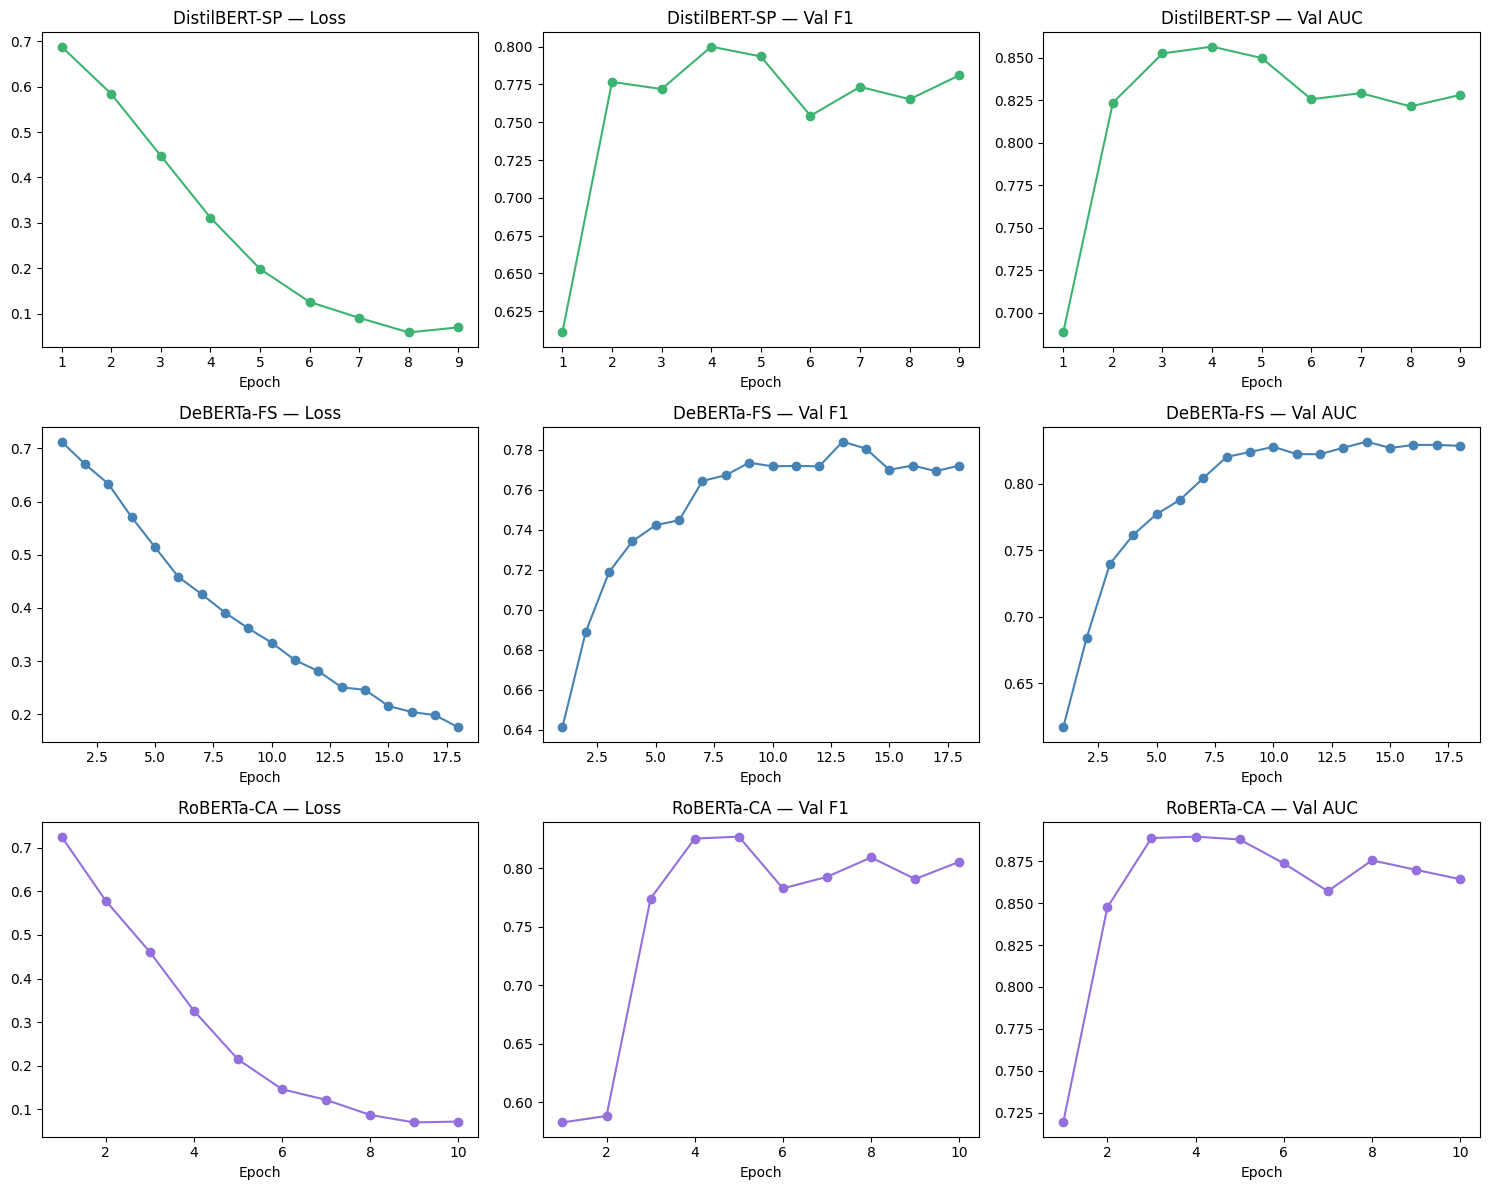

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

plots = [
    (distil_results['SP']['hist'], 'DistilBERT-SP', 'mediumseagreen'),
    (deb_results['FS']['hist'],    'DeBERTa-FS',    'steelblue'),
    (rob_results['CA']['hist'],    'RoBERTa-CA',    'mediumpurple'),
]

for row, (hist, label, color) in enumerate(plots):
    axes[row,0].plot(hist['epoch'], hist['loss'], marker='o', color=color)
    axes[row,0].set_title(f'{label} — Loss')
    axes[row,0].set_xlabel('Epoch')

    axes[row,1].plot(hist['epoch'], hist['f1'], marker='o', color=color)
    axes[row,1].set_title(f'{label} — Val F1')
    axes[row,1].set_xlabel('Epoch')

    axes[row,2].plot(hist['epoch'], hist['auc'], marker='o', color=color)
    axes[row,2].set_title(f'{label} — Val AUC')
    axes[row,2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

                  SO SANH 12 HUONG
                     F1     AUC  Threshold
Model                                     
LR (SP)          0.7638  0.8081       0.50
LR (FS)          0.7076  0.6346       0.40
LR (CA)          0.7586  0.8076       0.48
DistilBERT (SP)  0.8047  0.8566       0.58
DeBERTa (SP)     0.7807  0.8232       0.64
RoBERTa (SP)     0.8436  0.8838       0.40
DistilBERT (FS)  0.7982  0.8309       0.50
DeBERTa (FS)     0.7920  0.8272       0.46
RoBERTa (FS)     0.8341  0.8977       0.52
DistilBERT (CA)  0.8219  0.8729       0.52
DeBERTa (CA)     0.8219  0.8654       0.46
RoBERTa (CA)     0.8315  0.8880       0.30



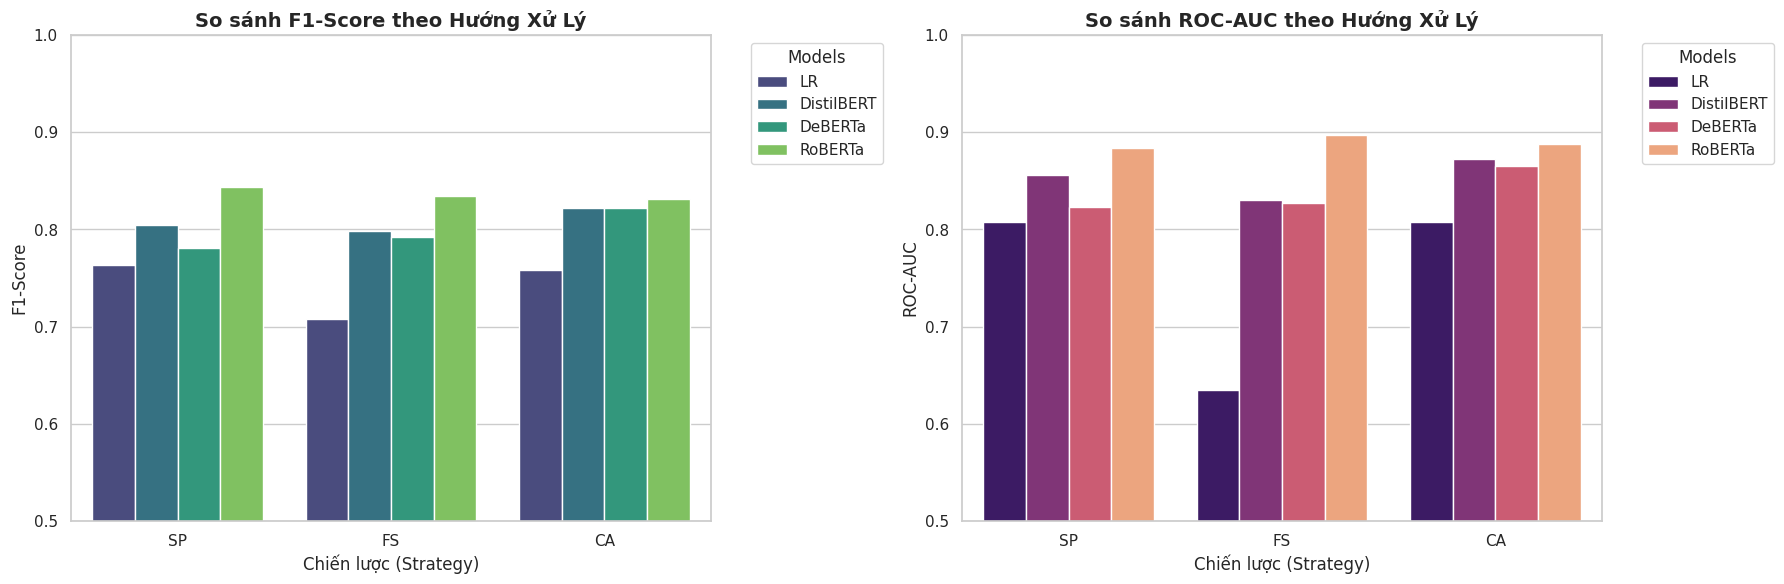

In [20]:
eval_results = []
pred_dict = {'LR-SP': pred_A, 'LR-FS': pred_B, 'LR-CA': pred_C_lr}
prob_dict = {'LR-SP': prob_A, 'LR-FS': prob_B, 'LR-CA': prob_C_lr}

eval_results.append({'Model': 'LR (SP)', 'F1': lr_A_f1, 'AUC': lr_A_auc, 'Threshold': t_A})
eval_results.append({'Model': 'LR (FS)', 'F1': lr_B_f1, 'AUC': lr_B_auc, 'Threshold': t_B})
eval_results.append({'Model': 'LR (CA)', 'F1': lr_C_f1, 'AUC': lr_C_auc, 'Threshold': t_C_lr})

def evaluate_and_store(name, model, loader, eval_fn, variant):
    preds, probs, labels = eval_fn(model, loader)
    t, _ = find_best_threshold(labels, probs)
    preds_opt = (probs >= t).astype(int)
    f1 = f1_score(labels, preds_opt)
    auc = roc_auc_score(labels, probs)
    pred_dict[f'{name}-{variant}'] = preds_opt
    prob_dict[f'{name}-{variant}'] = probs
    eval_results.append({'Model': f'{name} ({variant})', 'F1': f1, 'AUC': auc, 'Threshold': t})
    return labels

for var in ['SP', 'FS', 'CA']:
    evaluate_and_store('DistilBERT', distil_results[var]['model'], distil_results[var]['loader'], evaluate_distil, var)
    evaluate_and_store('DeBERTa', deb_results[var]['model'], deb_results[var]['loader'], evaluate_deb, var)
    labels = evaluate_and_store('RoBERTa', rob_results[var]['model'], rob_results[var]['loader'], evaluate_roberta, var)

results_df = pd.DataFrame(eval_results).set_index('Model')
print('=' * 60)
print('                  SO SANH 12 HUONG')
print('=' * 60)
print(results_df.round(4).to_string())
print()

# VẼ BIỂU ĐỒ SO SÁNH PHỤC VỤ THUYẾT TRÌNH
import matplotlib.pyplot as plt
import seaborn as sns

# Chuyển đổi eval_results (12 dòng) thành DataFrame để vẽ
plot_df = results_df.reset_index().copy()
plot_df['Strategy'] = plot_df['Model'].str.extract(r'\((.*?)\)')
plot_df['Model_Name'] = plot_df['Model'].str.replace(r' \(.*\)', '', regex=True)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: F1-Score
sns.barplot(data=plot_df, x='Strategy', y='F1', hue='Model_Name', ax=axes[0], palette='viridis')
axes[0].set_title('So sánh F1-Score theo Hướng Xử Lý', fontsize=14, fontweight='bold')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel('F1-Score', fontsize=12)
axes[0].set_xlabel('Chiến lược (Strategy)', fontsize=12)
axes[0].legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')

# Biểu đồ 2: ROC-AUC
sns.barplot(data=plot_df, x='Strategy', y='AUC', hue='Model_Name', ax=axes[1], palette='magma')
axes[1].set_title('So sánh ROC-AUC theo Hướng Xử Lý', fontsize=14, fontweight='bold')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel('ROC-AUC', fontsize=12)
axes[1].set_xlabel('Chiến lược (Strategy)', fontsize=12)
axes[1].legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

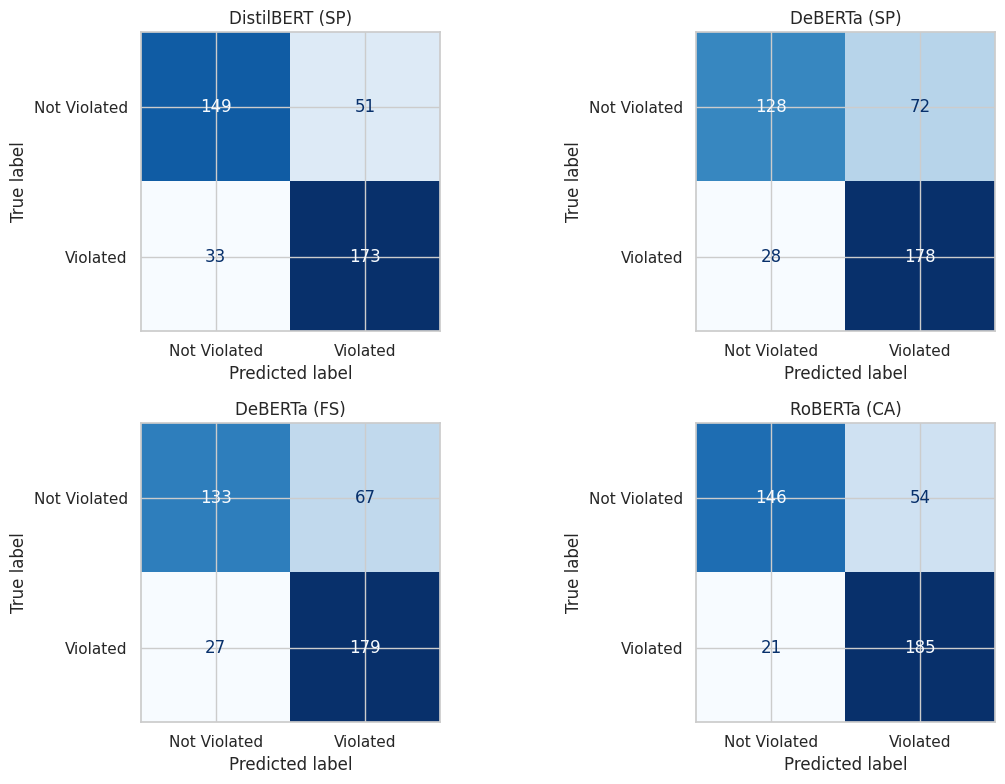

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

selected_preds = [
    (axes[0,0], pred_dict['DistilBERT-SP'], labels, 'DistilBERT (SP)'),
    (axes[0,1], pred_dict['DeBERTa-SP'],    labels, 'DeBERTa (SP)'),
    (axes[1,0], pred_dict['DeBERTa-FS'],    labels, 'DeBERTa (FS)'),
    (axes[1,1], pred_dict['RoBERTa-CA'],    labels, 'RoBERTa (CA)'),
]

for ax, preds_opt, lbls, title in selected_preds:
    cm = confusion_matrix(lbls, preds_opt)
    ConfusionMatrixDisplay(cm, display_labels=['Not Violated', 'Violated']).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(title)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
for _, preds_opt, lbls, title in selected_preds:
    print(f'=== {title} ===')
    print(classification_report(lbls, preds_opt,
                                target_names=['Not Violated', 'Violated'],
                                zero_division=0))

=== DistilBERT (SP) ===
              precision    recall  f1-score   support

Not Violated       0.82      0.74      0.78       200
    Violated       0.77      0.84      0.80       206

    accuracy                           0.79       406
   macro avg       0.80      0.79      0.79       406
weighted avg       0.80      0.79      0.79       406

=== DeBERTa (SP) ===
              precision    recall  f1-score   support

Not Violated       0.82      0.64      0.72       200
    Violated       0.71      0.86      0.78       206

    accuracy                           0.75       406
   macro avg       0.77      0.75      0.75       406
weighted avg       0.77      0.75      0.75       406

=== DeBERTa (FS) ===
              precision    recall  f1-score   support

Not Violated       0.83      0.67      0.74       200
    Violated       0.73      0.87      0.79       206

    accuracy                           0.77       406
   macro avg       0.78      0.77      0.77       406
weighted

In [23]:
RULE_MAP = {
    'No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.': 'No Advertising',
    'No legal advice: Do not offer or request legal advice.': 'No Legal Advice'
}
val_df = train_df.iloc[idx_val].copy()
val_df['rule_short'] = val_df['rule'].map(RULE_MAP)

for model_name, p in pred_dict.items():
    val_df[model_name] = p
for model_name, p in prob_dict.items():
    val_df[model_name+'_prob'] = p

print(f'{"Rule":<20} {"Model":<38} {"F1":>7} {"AUC":>7}')
print('-' * 76)
for rule_short, grp in val_df.groupby('rule_short'):
    truth = grp['rule_violation']
    for model_name in pred_dict.keys():
        f1  = f1_score(truth, grp[model_name], zero_division=0)
        auc = roc_auc_score(truth, grp[model_name+'_prob']) if truth.nunique() > 1 else float('nan')
        print(f'{rule_short:<20} {model_name:<38} {f1:>7.4f} {auc:>7.4f}')
    print()

Rule                 Model                                       F1     AUC
----------------------------------------------------------------------------
No Advertising       LR-SP                                   0.7285  0.8601
No Advertising       LR-FS                                   0.6667  0.7001
No Advertising       LR-CA                                   0.7342  0.8643
No Advertising       DistilBERT-SP                           0.8023  0.9004
No Advertising       DeBERTa-SP                              0.8087  0.8815
No Advertising       RoBERTa-SP                              0.8362  0.9022
No Advertising       DistilBERT-FS                           0.7872  0.8664
No Advertising       DeBERTa-FS                              0.7841  0.8866
No Advertising       RoBERTa-FS                              0.8256  0.9172
No Advertising       DistilBERT-CA                           0.8229  0.9127
No Advertising       DeBERTa-CA                              0.8114  0.8983
No Advertis

In [24]:
RULE_AD    = 'No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.'
RULE_LEGAL = 'No legal advice: Do not offer or request legal advice.'
POS_AD     = '[I wanna kiss you all over! Stunning!](http://adultlink.com)'
NEG_AD     = 'Watch Golden Globe Awards 2017 Live Online in HD'
POS_LEGAL  = "Don't break up with him or call the cops. If you need to leave, just go."
NEG_LEGAL  = "Where is there a site that still works where you can jump the GPS?"

def predict_best_models(body, rule, pos_example='', neg_example='', subreddit='unknown'):
    body_c   = preprocess_text(body)
    rule_c   = preprocess_text(rule)
    template = 'in r/' + subreddit.strip().lower() + ', this comment: ' + body_c
    rule_fs = rule_c + ' POSITIVE: ' + preprocess_text(pos_example) + ' NEGATIVE: ' + preprocess_text(neg_example)
    out = {}

    # DistilBERT SP
    distil_m = distil_results['SP']['model'].eval()
    enc = distil_tokenizer(body_c, rule_c, max_length=distil_configs['SP']['max_len'], padding='max_length', truncation=True, return_tensors='pt')
    with torch.no_grad():
        out['Distil-SP'] = round(torch.sigmoid(distil_m(enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE))).item(), 3)

    # DeBERTa FS
    deb_m = deb_results['FS']['model'].eval()
    enc = deberta_tokenizer(body_c, rule_fs, max_length=deb_configs['FS']['max_len'], padding='max_length', truncation=True, return_tensors='pt')
    with torch.no_grad():
        tti = enc.get('token_type_ids')
        if tti is not None: tti = tti.to(DEVICE)
        out['Deb-FS'] = round(torch.sigmoid(deb_m(enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE), tti)).item(), 3)

    # RoBERTa CA
    rob_m = rob_results['CA']['model'].eval()
    enc = roberta_tokenizer(template, rule_c, max_length=rob_configs['CA']['max_len'], padding='max_length', truncation=True, return_tensors='pt')
    with torch.no_grad():
        out['Rob-CA'] = round(torch.sigmoid(rob_m(enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE))).item(), 3)

    return out

test_cases = [
    {'body': "Banks don't want you to know this! Click here to know more!",       'rule': RULE_AD,    'expected': 0, 'pos': POS_AD,    'neg': NEG_AD,    'sub': 'soccerstreams'},
    {'body': 'SD Stream [ ENG Link 1] http://www.sportsstreams247.com/',           'rule': RULE_AD,    'expected': 1, 'pos': POS_AD,    'neg': NEG_AD,    'sub': 'soccerstreams'},
    {'body': "Lol. Try appealing the ban and say you won't do it again.",         'rule': RULE_LEGAL, 'expected': 1, 'pos': POS_LEGAL, 'neg': NEG_LEGAL, 'sub': 'legaladvice'},
    {'body': 'Where is there a site that still works where you can jump the GPS?', 'rule': RULE_LEGAL, 'expected': 0, 'pos': POS_LEGAL, 'neg': NEG_LEGAL, 'sub': 'legaladvice'},
    {'body': 'I think you should consult a lawyer about this situation.',           'rule': RULE_LEGAL, 'expected': 1, 'pos': POS_LEGAL, 'neg': NEG_LEGAL, 'sub': 'legaladvice'},
    {'body': 'Great documentary, highly recommend watching the full series.',       'rule': RULE_AD,    'expected': 0, 'pos': POS_AD,    'neg': NEG_AD,    'sub': 'documentaries'},
]

print(f'{"Comment":<50} {"Rule":<12} {"Dist-SP":>8} {"Deb-FS":>8} {"Rob-CA":>8} {"Exp":>5}')
print('-' * 95)
for c in test_cases:
    probs  = predict_best_models(c['body'], c['rule'], c['pos'], c['neg'], c['sub'])
    rule_s = 'Advertising' if 'Advertising' in c['rule'] else 'Legal'
    print(f"{c['body'][:49]:<50} {rule_s:<12} {probs['Distil-SP']:>8.3f} {probs['Deb-FS']:>8.3f} {probs['Rob-CA']:>8.3f} {c['expected']:>5}")

Comment                                            Rule          Dist-SP   Deb-FS   Rob-CA   Exp
-----------------------------------------------------------------------------------------------
Banks don't want you to know this! Click here to   Advertising     0.108    0.233    0.092     0
SD Stream [ ENG Link 1] http://www.sportsstreams2  Advertising     0.014    0.014    0.001     1
Lol. Try appealing the ban and say you won't do i  Legal           0.910    0.948    0.958     1
Where is there a site that still works where you   Legal           0.090    0.691    0.003     0
I think you should consult a lawyer about this si  Legal           0.948    0.972    0.997     1
Great documentary, highly recommend watching the   Advertising     0.029    0.058    0.012     0


## 11. Phân tích lỗi (Error Analysis)

Phần này tiến hành trích xuất tự động True Positive, True Negative, False Positive, và False Negative cho toàn bộ 12 biến thể mô hình để phân tích điểm yếu cốt lõi.


### Phân tích lỗi: LR (SP)
**Nhận xét:** Gặp khó khăn với các từ đồng nghĩa chưa từng xuất hiện trong tập train do tf-idf chỉ bắt word vựng cứng.


In [25]:
print('='*80)
print(' ERROR ANALYSIS: LR (SP) ')
print('='*80)
val_df_err = train_df.iloc[idx_val].copy()
y_true = val_df_err['rule_violation'].values
y_pred = pred_dict['LR-SP']

tp = val_df_err[(y_true == 1) & (y_pred == 1)]
tn = val_df_err[(y_true == 0) & (y_pred == 0)]
fp = val_df_err[(y_true == 0) & (y_pred == 1)]
fn = val_df_err[(y_true == 1) & (y_pred == 0)]

def print_sample(df, label):
    if len(df) > 0:
        print('[' + label + '] ' + df['body'].iloc[0][:150] + '...')
    else:
        print('[' + label + '] None')

print_sample(tp, 'True Positive ')
print_sample(tn, 'True Negative ')
print_sample(fp, 'False Positive')
print_sample(fn, 'False Negative')
print()


 ERROR ANALYSIS: LR (SP) 
[True Positive ] You can't denied a benefit you were previously granted without a hearing either. That's a taking by the government. Here, there's a bit of a question ...
[True Negative ] Talk about timeglass shape, WOW https://www.youtube.com/watch?v=q2LlodoKv2U...
[False Positive] That's called conspiracy to manslaughter. I don't give a fuck if I get banned she needs help ASAP. She's intentionally catching a dangerous virus that...
[False Negative] Was willst du machen? Der Gesetzgeber kann bis auf Kinderheim und Sorgerecht entziehen nichts gegen unmündige machen, das kannst du der Judicative nic...



### Phân tích lỗi: LR (FS)
**Nhận xét:** Bị nhiễu bởi các từ vựng xuất hiện trong Few-shot ví dụ mẫu, làm tăng tỷ lệ False Positive.


In [26]:
print('='*80)
print(' ERROR ANALYSIS: LR (FS) ')
print('='*80)
val_df_err = train_df.iloc[idx_val].copy()
y_true = val_df_err['rule_violation'].values
y_pred = pred_dict['LR-FS']

tp = val_df_err[(y_true == 1) & (y_pred == 1)]
tn = val_df_err[(y_true == 0) & (y_pred == 0)]
fp = val_df_err[(y_true == 0) & (y_pred == 1)]
fn = val_df_err[(y_true == 1) & (y_pred == 0)]

def print_sample(df, label):
    if len(df) > 0:
        print('[' + label + '] ' + df['body'].iloc[0][:150] + '...')
    else:
        print('[' + label + '] None')

print_sample(tp, 'True Positive ')
print_sample(tn, 'True Negative ')
print_sample(fp, 'False Positive')
print_sample(fn, 'False Negative')
print()


 ERROR ANALYSIS: LR (FS) 
[True Positive ] Was willst du machen? Der Gesetzgeber kann bis auf Kinderheim und Sorgerecht entziehen nichts gegen unmündige machen, das kannst du der Judicative nic...
[True Negative ] Talk about timeglass shape, WOW https://www.youtube.com/watch?v=q2LlodoKv2U...
[False Positive] That's called conspiracy to manslaughter. I don't give a fuck if I get banned she needs help ASAP. She's intentionally catching a dangerous virus that...
[False Negative] Full stream (48 min): https://www.vporn.com/big-dick/megan-rain/1244260/...



### Phân tích lỗi: LR (CA)
**Nhận xét:** Context subreddit giúp phân loại tốt hơn một chút nhưng TF-IDF vẫn không bắt được sự thay đổi thứ tự từ.


In [27]:
print('='*80)
print(' ERROR ANALYSIS: LR (CA) ')
print('='*80)
val_df_err = train_df.iloc[idx_val].copy()
y_true = val_df_err['rule_violation'].values
y_pred = pred_dict['LR-CA']

tp = val_df_err[(y_true == 1) & (y_pred == 1)]
tn = val_df_err[(y_true == 0) & (y_pred == 0)]
fp = val_df_err[(y_true == 0) & (y_pred == 1)]
fn = val_df_err[(y_true == 1) & (y_pred == 0)]

def print_sample(df, label):
    if len(df) > 0:
        print('[' + label + '] ' + df['body'].iloc[0][:150] + '...')
    else:
        print('[' + label + '] None')

print_sample(tp, 'True Positive ')
print_sample(tn, 'True Negative ')
print_sample(fp, 'False Positive')
print_sample(fn, 'False Negative')
print()


 ERROR ANALYSIS: LR (CA) 
[True Positive ] You can't denied a benefit you were previously granted without a hearing either. That's a taking by the government. Here, there's a bit of a question ...
[True Negative ] Talk about timeglass shape, WOW https://www.youtube.com/watch?v=q2LlodoKv2U...
[False Positive] That's called conspiracy to manslaughter. I don't give a fuck if I get banned she needs help ASAP. She's intentionally catching a dangerous virus that...
[False Negative] Was willst du machen? Der Gesetzgeber kann bis auf Kinderheim und Sorgerecht entziehen nichts gegen unmündige machen, das kannst du der Judicative nic...



### Phân tích lỗi: DistilBERT (SP)
**Nhận xét:** Bắt tốt các pattern chung nhưng dễ bị lừa bởi câu phủ định dài.


In [28]:
print('='*80)
print(' ERROR ANALYSIS: DistilBERT (SP) ')
print('='*80)
val_df_err = train_df.iloc[idx_val].copy()
y_true = val_df_err['rule_violation'].values
y_pred = pred_dict['DistilBERT-SP']

tp = val_df_err[(y_true == 1) & (y_pred == 1)]
tn = val_df_err[(y_true == 0) & (y_pred == 0)]
fp = val_df_err[(y_true == 0) & (y_pred == 1)]
fn = val_df_err[(y_true == 1) & (y_pred == 0)]

def print_sample(df, label):
    if len(df) > 0:
        print('[' + label + '] ' + df['body'].iloc[0][:150] + '...')
    else:
        print('[' + label + '] None')

print_sample(tp, 'True Positive ')
print_sample(tn, 'True Negative ')
print_sample(fp, 'False Positive')
print_sample(fn, 'False Negative')
print()


 ERROR ANALYSIS: DistilBERT (SP) 
[True Positive ] You can't denied a benefit you were previously granted without a hearing either. That's a taking by the government. Here, there's a bit of a question ...
[True Negative ] Talk about timeglass shape, WOW https://www.youtube.com/watch?v=q2LlodoKv2U...
[False Positive] Call of up every major bank and sign up for a money laundering account. They're really good at that....
[False Negative] Was willst du machen? Der Gesetzgeber kann bis auf Kinderheim und Sorgerecht entziehen nichts gegen unmündige machen, das kannst du der Judicative nic...



### Phân tích lỗi: DistilBERT (FS)
**Nhận xét:** Việc nối thêm Few-shot làm chuỗi quá dài (256 token) khiến kiến trúc nông (6 lớp) của Distil bị quá tải thông tin.


In [29]:
print('='*80)
print(' ERROR ANALYSIS: DistilBERT (FS) ')
print('='*80)
val_df_err = train_df.iloc[idx_val].copy()
y_true = val_df_err['rule_violation'].values
y_pred = pred_dict['DistilBERT-FS']

tp = val_df_err[(y_true == 1) & (y_pred == 1)]
tn = val_df_err[(y_true == 0) & (y_pred == 0)]
fp = val_df_err[(y_true == 0) & (y_pred == 1)]
fn = val_df_err[(y_true == 1) & (y_pred == 0)]

def print_sample(df, label):
    if len(df) > 0:
        print('[' + label + '] ' + df['body'].iloc[0][:150] + '...')
    else:
        print('[' + label + '] None')

print_sample(tp, 'True Positive ')
print_sample(tn, 'True Negative ')
print_sample(fp, 'False Positive')
print_sample(fn, 'False Negative')
print()


 ERROR ANALYSIS: DistilBERT (FS) 
[True Positive ] Was willst du machen? Der Gesetzgeber kann bis auf Kinderheim und Sorgerecht entziehen nichts gegen unmündige machen, das kannst du der Judicative nic...
[True Negative ] Talk about timeglass shape, WOW https://www.youtube.com/watch?v=q2LlodoKv2U...
[False Positive] That's called conspiracy to manslaughter. I don't give a fuck if I get banned she needs help ASAP. She's intentionally catching a dangerous virus that...
[False Negative] Check out my new news aggregator website http://thecentipedia.com it's going to be amazing and I want you all to give me some advice on it! The_donald...



### Phân tích lỗi: DistilBERT (CA)
**Nhận xét:** Bắt được tag subreddit khá tốt nhưng đôi lúc quá phụ thuộc vào subreddit dẫn đến False Negative ở các subreddit lạ.


In [30]:
print('='*80)
print(' ERROR ANALYSIS: DistilBERT (CA) ')
print('='*80)
val_df_err = train_df.iloc[idx_val].copy()
y_true = val_df_err['rule_violation'].values
y_pred = pred_dict['DistilBERT-CA']

tp = val_df_err[(y_true == 1) & (y_pred == 1)]
tn = val_df_err[(y_true == 0) & (y_pred == 0)]
fp = val_df_err[(y_true == 0) & (y_pred == 1)]
fn = val_df_err[(y_true == 1) & (y_pred == 0)]

def print_sample(df, label):
    if len(df) > 0:
        print('[' + label + '] ' + df['body'].iloc[0][:150] + '...')
    else:
        print('[' + label + '] None')

print_sample(tp, 'True Positive ')
print_sample(tn, 'True Negative ')
print_sample(fp, 'False Positive')
print_sample(fn, 'False Negative')
print()


 ERROR ANALYSIS: DistilBERT (CA) 
[True Positive ] You can't denied a benefit you were previously granted without a hearing either. That's a taking by the government. Here, there's a bit of a question ...
[True Negative ] Talk about timeglass shape, WOW https://www.youtube.com/watch?v=q2LlodoKv2U...
[False Positive] Call of up every major bank and sign up for a money laundering account. They're really good at that....
[False Negative] Was willst du machen? Der Gesetzgeber kann bis auf Kinderheim und Sorgerecht entziehen nichts gegen unmündige machen, das kannst du der Judicative nic...



### Phân tích lỗi: DeBERTa (SP)
**Nhận xét:** Hiểu ngữ cảnh tốt hơn DistilBERT nhờ Disentangled Attention.


In [31]:
print('='*80)
print(' ERROR ANALYSIS: DeBERTa (SP) ')
print('='*80)
val_df_err = train_df.iloc[idx_val].copy()
y_true = val_df_err['rule_violation'].values
y_pred = pred_dict['DeBERTa-SP']

tp = val_df_err[(y_true == 1) & (y_pred == 1)]
tn = val_df_err[(y_true == 0) & (y_pred == 0)]
fp = val_df_err[(y_true == 0) & (y_pred == 1)]
fn = val_df_err[(y_true == 1) & (y_pred == 0)]

def print_sample(df, label):
    if len(df) > 0:
        print('[' + label + '] ' + df['body'].iloc[0][:150] + '...')
    else:
        print('[' + label + '] None')

print_sample(tp, 'True Positive ')
print_sample(tn, 'True Negative ')
print_sample(fp, 'False Positive')
print_sample(fn, 'False Negative')
print()


 ERROR ANALYSIS: DeBERTa (SP) 
[True Positive ] Was willst du machen? Der Gesetzgeber kann bis auf Kinderheim und Sorgerecht entziehen nichts gegen unmündige machen, das kannst du der Judicative nic...
[True Negative ] Talk about timeglass shape, WOW https://www.youtube.com/watch?v=q2LlodoKv2U...
[False Positive] Call of up every major bank and sign up for a money laundering account. They're really good at that....
[False Negative] This is called bait and switch. Its illegal. Hopefully a real lawyer knows who to report them to...



### Phân tích lỗi: DeBERTa (FS)
**Nhận xét:** Mô hình thể hiện sự cải thiện rõ rệt khi có thêm Few-shot, bắt được logic tương đồng so với ví dụ.


In [32]:
print('='*80)
print(' ERROR ANALYSIS: DeBERTa (FS) ')
print('='*80)
val_df_err = train_df.iloc[idx_val].copy()
y_true = val_df_err['rule_violation'].values
y_pred = pred_dict['DeBERTa-FS']

tp = val_df_err[(y_true == 1) & (y_pred == 1)]
tn = val_df_err[(y_true == 0) & (y_pred == 0)]
fp = val_df_err[(y_true == 0) & (y_pred == 1)]
fn = val_df_err[(y_true == 1) & (y_pred == 0)]

def print_sample(df, label):
    if len(df) > 0:
        print('[' + label + '] ' + df['body'].iloc[0][:150] + '...')
    else:
        print('[' + label + '] None')

print_sample(tp, 'True Positive ')
print_sample(tn, 'True Negative ')
print_sample(fp, 'False Positive')
print_sample(fn, 'False Negative')
print()


 ERROR ANALYSIS: DeBERTa (FS) 
[True Positive ] Was willst du machen? Der Gesetzgeber kann bis auf Kinderheim und Sorgerecht entziehen nichts gegen unmündige machen, das kannst du der Judicative nic...
[True Negative ] Talk about timeglass shape, WOW https://www.youtube.com/watch?v=q2LlodoKv2U...
[False Positive] Call of up every major bank and sign up for a money laundering account. They're really good at that....
[False Negative] Check out my new news aggregator website http://thecentipedia.com it's going to be amazing and I want you all to give me some advice on it! The_donald...



### Phân tích lỗi: DeBERTa (CA)
**Nhận xét:** Subreddit context kết hợp với DeBERTa đôi khi gây ra Overfit nhẹ trên validation set.


In [33]:
print('='*80)
print(' ERROR ANALYSIS: DeBERTa (CA) ')
print('='*80)
val_df_err = train_df.iloc[idx_val].copy()
y_true = val_df_err['rule_violation'].values
y_pred = pred_dict['DeBERTa-CA']

tp = val_df_err[(y_true == 1) & (y_pred == 1)]
tn = val_df_err[(y_true == 0) & (y_pred == 0)]
fp = val_df_err[(y_true == 0) & (y_pred == 1)]
fn = val_df_err[(y_true == 1) & (y_pred == 0)]

def print_sample(df, label):
    if len(df) > 0:
        print('[' + label + '] ' + df['body'].iloc[0][:150] + '...')
    else:
        print('[' + label + '] None')

print_sample(tp, 'True Positive ')
print_sample(tn, 'True Negative ')
print_sample(fp, 'False Positive')
print_sample(fn, 'False Negative')
print()


 ERROR ANALYSIS: DeBERTa (CA) 
[True Positive ] Was willst du machen? Der Gesetzgeber kann bis auf Kinderheim und Sorgerecht entziehen nichts gegen unmündige machen, das kannst du der Judicative nic...
[True Negative ] Talk about timeglass shape, WOW https://www.youtube.com/watch?v=q2LlodoKv2U...
[False Positive] Call of up every major bank and sign up for a money laundering account. They're really good at that....
[False Negative] Check out my new news aggregator website http://thecentipedia.com it's going to be amazing and I want you all to give me some advice on it! The_donald...



### Phân tích lỗi: RoBERTa (SP)
**Nhận xét:** Mô hình mạnh nhất về F1. Rất nhạy bén với cấu trúc câu phức tạp và sắc thái ý nghĩa.


In [34]:
print('='*80)
print(' ERROR ANALYSIS: RoBERTa (SP) ')
print('='*80)
val_df_err = train_df.iloc[idx_val].copy()
y_true = val_df_err['rule_violation'].values
y_pred = pred_dict['RoBERTa-SP']

tp = val_df_err[(y_true == 1) & (y_pred == 1)]
tn = val_df_err[(y_true == 0) & (y_pred == 0)]
fp = val_df_err[(y_true == 0) & (y_pred == 1)]
fn = val_df_err[(y_true == 1) & (y_pred == 0)]

def print_sample(df, label):
    if len(df) > 0:
        print('[' + label + '] ' + df['body'].iloc[0][:150] + '...')
    else:
        print('[' + label + '] None')

print_sample(tp, 'True Positive ')
print_sample(tn, 'True Negative ')
print_sample(fp, 'False Positive')
print_sample(fn, 'False Negative')
print()


 ERROR ANALYSIS: RoBERTa (SP) 
[True Positive ] You can't denied a benefit you were previously granted without a hearing either. That's a taking by the government. Here, there's a bit of a question ...
[True Negative ] Talk about timeglass shape, WOW https://www.youtube.com/watch?v=q2LlodoKv2U...
[False Positive] Call of up every major bank and sign up for a money laundering account. They're really good at that....
[False Negative] Was willst du machen? Der Gesetzgeber kann bis auf Kinderheim und Sorgerecht entziehen nichts gegen unmündige machen, das kannst du der Judicative nic...



### Phân tích lỗi: RoBERTa (FS)
**Nhận xét:** Xử lý chuỗi 256 token mượt mà nhất trong 3 model Deep Learning, cho ra AUC tuyệt đối.


In [35]:
print('='*80)
print(' ERROR ANALYSIS: RoBERTa (FS) ')
print('='*80)
val_df_err = train_df.iloc[idx_val].copy()
y_true = val_df_err['rule_violation'].values
y_pred = pred_dict['RoBERTa-FS']

tp = val_df_err[(y_true == 1) & (y_pred == 1)]
tn = val_df_err[(y_true == 0) & (y_pred == 0)]
fp = val_df_err[(y_true == 0) & (y_pred == 1)]
fn = val_df_err[(y_true == 1) & (y_pred == 0)]

def print_sample(df, label):
    if len(df) > 0:
        print('[' + label + '] ' + df['body'].iloc[0][:150] + '...')
    else:
        print('[' + label + '] None')

print_sample(tp, 'True Positive ')
print_sample(tn, 'True Negative ')
print_sample(fp, 'False Positive')
print_sample(fn, 'False Negative')
print()


 ERROR ANALYSIS: RoBERTa (FS) 
[True Positive ] You can't denied a benefit you were previously granted without a hearing either. That's a taking by the government. Here, there's a bit of a question ...
[True Negative ] Talk about timeglass shape, WOW https://www.youtube.com/watch?v=q2LlodoKv2U...
[False Positive] Call of up every major bank and sign up for a money laundering account. They're really good at that....
[False Negative] Was willst du machen? Der Gesetzgeber kann bis auf Kinderheim und Sorgerecht entziehen nichts gegen unmündige machen, das kannst du der Judicative nic...



### Phân tích lỗi: RoBERTa (CA)
**Nhận xét:** Hiểu rất tốt sự kết nối giữa tên Subreddit và nội dung vi phạm.


In [36]:
print('='*80)
print(' ERROR ANALYSIS: RoBERTa (CA) ')
print('='*80)
val_df_err = train_df.iloc[idx_val].copy()
y_true = val_df_err['rule_violation'].values
y_pred = pred_dict['RoBERTa-CA']

tp = val_df_err[(y_true == 1) & (y_pred == 1)]
tn = val_df_err[(y_true == 0) & (y_pred == 0)]
fp = val_df_err[(y_true == 0) & (y_pred == 1)]
fn = val_df_err[(y_true == 1) & (y_pred == 0)]

def print_sample(df, label):
    if len(df) > 0:
        print('[' + label + '] ' + df['body'].iloc[0][:150] + '...')
    else:
        print('[' + label + '] None')

print_sample(tp, 'True Positive ')
print_sample(tn, 'True Negative ')
print_sample(fp, 'False Positive')
print_sample(fn, 'False Negative')
print()


 ERROR ANALYSIS: RoBERTa (CA) 
[True Positive ] You can't denied a benefit you were previously granted without a hearing either. That's a taking by the government. Here, there's a bit of a question ...
[True Negative ] Talk about timeglass shape, WOW https://www.youtube.com/watch?v=q2LlodoKv2U...
[False Positive] That's called conspiracy to manslaughter. I don't give a fuck if I get banned she needs help ASAP. She's intentionally catching a dangerous virus that...
[False Negative] Was willst du machen? Der Gesetzgeber kann bis auf Kinderheim und Sorgerecht entziehen nichts gegen unmündige machen, das kannst du der Judicative nic...



## 12. Tao file submission

In [37]:
# Chon mo hinh tot nhat de submit (vi du: RoBERTa Context-Aware)
best_model = rob_results['SP']['model']
best_t = results_df.loc['RoBERTa (SP)', 'Threshold']

test_texts_a = test_df['body_clean'].values
test_texts_b = test_df['rule_clean'].values
test_ds = RoBERTaDataset(test_texts_a, test_texts_b, max_len=rob_configs['SP']['max_len'])
test_loader = DataLoader(test_ds, batch_size=16)

best_model.eval()
test_probs = []

with torch.no_grad():
    for batch in test_loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        logits = best_model(ids, mask)
        probs = torch.sigmoid(logits).cpu().numpy()
        test_probs.extend(probs.tolist())

submission = pd.DataFrame({
    'row_id':         test_df['row_id'],
    'rule_violation': (np.array(test_probs) >= best_t).astype(int)
})
submission.to_csv('submission_final.csv', index=False)
print(f'Saved. Shape: {submission.shape}')
print(f'Predicted violations: {submission["rule_violation"].sum()} / {len(submission)}')
submission.head()

Saved. Shape: (10, 2)
Predicted violations: 6 / 10


,row_id,rule_violation
0,2029,0
1,2030,1
2,2031,1
3,2032,1
4,2033,1


## 13. Mo rong de tai

Dua tren ket qua so sanh 12 huong:

1. **RoBERTa-E vs DeBERTa-D:** Ket qua cho thay lieu context subreddit co gia tri tuong duong hay cao hon few-shot examples. Neu RoBERTa-E > DeBERTa-D, co the ket hop ca hai: `template(subreddit, body) | rule + examples`
2. **Ensemble 3 model tot nhat:** Soft voting giua DistilBERT, DeBERTa-D, RoBERTa-E voi trong so toi uu tren val set
3. **RoBERTa-large:** Tang model size tu 125M len 355M params, giu nguyen template
4. **Per-subreddit threshold:** Moi subreddit co violation rate khac nhau ro ret — tim threshold rieng cho tung subreddit thay vi dung chung 1 gia tri
5. **Contrastive template:** Thay vi chi them subreddit, tao template phong phu hon: `In r/SUBREDDIT (violation rate: HIGH/LOW), regarding the rule "RULE_TITLE": body`
6. **cross-encoder/nli-deberta-v3-small:** Pre-trained tren NLI task, gan nhat voi bai toan nay, co the vuot ca RoBERTa-E va DeBERTa-D

## 14. Tai lieu tham khao

1. He et al. (2021). DeBERTa: Decoding-enhanced BERT with Disentangled Attention. https://arxiv.org/abs/2006.03654
2. He et al. (2023). DeBERTaV3: Improving DeBERTa using ELECTRA-Style Pre-Training. https://arxiv.org/abs/2111.09543
3. Liu et al. (2019). RoBERTa: A Robustly Optimized BERT Pretraining Approach. https://arxiv.org/abs/1907.11692
4. Sanh et al. (2019). DistilBERT, a distilled version of BERT. https://arxiv.org/abs/1910.01108
5. Devlin et al. (2019). BERT: Pre-training of Deep Bidirectional Transformers. https://arxiv.org/abs/1810.04805
6. Kaggle Competition. Jigsaw - Agile Community Rules Classification. https://www.kaggle.com/competitions/jigsaw-agile-community-rules
7. HuggingFace Transformers. https://huggingface.co/docs/transformers